Code Created by Mourad Ali

Code Reviewed by Bora yavuz and Tara Khobiary

*   Comparison Dataframe made for comparing actual and predicted results for logistic regression model
*   Created confusion matrix for logistic regression model to check results
*   Used KNN on test data to predict all test data

Code Leveraged from Code Reuse Session 2,Block 1


In [ ]:
#I imported a suitable Python library to load and access my datase
import pandas as pd

Code Leveraged from Code Reuse Session 2,Block 2


In [ ]:
#I then used a function to load my dataset file
data = pd.read_csv('/content/5DATA002W.2 Coursework Dataset(cleaned).csv')

Code Leveraged from Code Reuse Session 2,Block 3


In [ ]:
# I then used a method to display the first 10 recorded patients values per data
data.head(15)

,Age,T_Stage,N_Stage,6th_Stage,Differentiated,Grade,A_Stage,Tumor_Size,Estrogen_Status,Progesterone_Status,Regional_Node_Examined,Regional_Node_Positive,Survival_Months,Mortality_Status
0,68,0,0,0,1,3,1,4.0,1,1,24.0,1,60,1
1,50,1,1,2,0,2,1,35.0,1,1,14.0,5,62,1
2,58,2,2,4,0,2,1,63.0,1,1,14.0,7,75,1
3,58,0,0,0,1,3,1,18.0,1,1,2.0,1,84,1
4,47,1,0,1,1,3,1,41.0,1,1,3.0,1,50,1
5,51,0,0,0,0,2,1,20.0,1,1,18.0,2,89,1
6,51,0,0,0,3,1,1,8.0,1,1,11.0,1,54,1
7,40,1,0,1,0,2,1,30.0,1,1,9.0,1,14,0
8,40,3,2,4,1,3,1,103.0,1,1,20.0,18,70,1
9,69,3,2,4,3,1,0,32.0,1,1,21.0,12,92,1


Code Leveraged from Code Reuse Session 2,Block 4


In [ ]:
#With this function i am able to view all the data types per variable in the dataset
#I will also be able to view the variables with missing entries
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4020 entries, 0 to 4019
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4020 non-null   int64  
 1   T_Stage                 4020 non-null   int64  
 2   N_Stage                 4020 non-null   int64  
 3   6th_Stage               4020 non-null   int64  
 4   Differentiated          4020 non-null   int64  
 5   Grade                   4020 non-null   int64  
 6   A_Stage                 4020 non-null   int64  
 7   Tumor_Size              4020 non-null   float64
 8   Estrogen_Status         4020 non-null   int64  
 9   Progesterone_Status     4020 non-null   int64  
 10  Regional_Node_Examined  4020 non-null   float64
 11  Regional_Node_Positive  4020 non-null   int64  
 12  Survival_Months         4020 non-null   int64  
 13  Mortality_Status        4020 non-null   int64  
dtypes: float64(2), int64(12)
memory usage: 4

Code Leveraged from Code Reuse Session 1,Block 6

In [ ]:
#This method only calculates and displays the dimensions of my dataset
data.shape

(4020, 14)

Code Leveraged from Code Reuse Session 1,Block 7

In [ ]:
#This method allows me to investigate any issues in your cancer patients’ data by displaying the basic descriptive statistics for the numeric variables only in the dataset
data.describe()

,Age,T_Stage,N_Stage,6th_Stage,Differentiated,Grade,A_Stage,Tumor_Size,Estrogen_Status,Progesterone_Status,Regional_Node_Examined,Regional_Node_Positive,Survival_Months,Mortality_Status
count,4020.000000,4020.000000,4020.000000,4020.000000,4020.000000,4020.000000,4020.000000,4020.000000,4020.000000,4020.000000,4020.000000,4020.000000,4020.000000,4020.000000
mean,53.991542,0.785075,0.437313,1.320149,0.690299,2.150995,0.977363,30.429923,0.933085,0.826617,14.363772,4.147512,71.305473,0.847015
std,8.969963,0.765697,0.692476,1.264967,1.016096,0.638280,0.148761,21.159700,0.249907,0.378625,8.125358,5.091830,22.917699,0.360018
min,30.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-75.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,47.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,16.000000,1.000000,1.000000,9.000000,1.000000,56.000000,1.000000
50%,54.000000,1.000000,0.000000,1.000000,0.000000,2.000000,1.000000,25.000000,1.000000,1.000000,14.000000,2.000000,73.000000,1.000000
75%,61.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,38.000000,1.000000,1.000000,19.000000,5.000000,90.000000,1.000000
max,89.000000,3.000000,2.000000,4.000000,3.000000,4.000000,1.000000,140.000000,1.000000,1.000000,61.000000,46.000000,107.000000,1.000000


Code Leveraged from Code Reuse Session 2,Block 5

In [ ]:
#I used a method to control the rows and columns truncation in my dataset as Pandas truncates the displayed data for larger datasets by defult.

pd.set_option('display.max_rows', 500)

pd.set_option('display.max_columns', 500)

pd.set_option('display.width', 150)

Code Leveraged from Code Reuse Session 2,Block 6

In [ ]:
#I declared my input variables (input features) and output variable (target feature)
feature_cols = ['Age', 'T_Stage', 'N_Stage', '6th_Stage', 'Differentiated', 'Grade', 'Tumor_Size',
                'Estrogen_Status', 'Progesterone_Status', 'Regional_Node_Examined', 'Regional_Node_Examined', 'Survival_Months']

X = data[feature_cols]

y = data['Mortality_Status']

Code Leveraged from seminar week 4, block 38

In [ ]:
#in order to scale my dataset i apply a minimum and a maximum normalisation
import numpy as np
X1 = (X - np.min(X)) / (np.max(X) - np.min(X))

Code Leveraged from Code Reuse Session 2,Block 7

In [ ]:
#I imported a library and function to randomly sample my training and test subsets
from sklearn.model_selection import train_test_split

Code Leveraged from Code Reuse Session 2,Block 8

In [ ]:
#I ensured that the sampled patients (instances) for the training subset do not change if the random sampling function is run multiple times
#It samples my dataset into training and test subsets with a ratio of my choice and ensures the reproducibility of the sampling output
X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42, stratify=y)

Code Leveraged from Code Reuse Session 2,Block 9

In [ ]:
#I imported a machine learning library to initiate the Logistic Regression modelling algorithm to build my machine learning models to predict a patient's mortality status
from sklearn.linear_model import LogisticRegression

Code Leveraged from Code Reuse Session 2,Block 10

In [ ]:
#This declares my Logistic Regression modelling algorithm in my Python environment
logreg = LogisticRegression()

Code Leveraged from Code Reuse Session 2,Block 11

In [ ]:
#I used a subset of my original dataset to estimate (set) the logistic regression algorithm coefficients and intercep
#I used a function that estimates my logreg algorithm learnable parameters using the desired sampled dataset
logreg.fit(X1_train, y_train)

LogisticRegression()

Code Leveraged from Code Reuse Session 2,Block 12

In [ ]:
#I decided to apply my model to make predictions
y_pred_train=logreg.predict(X1_train)

Code Leveraged from Code Reuse Session 2,Block 13

In [ ]:
#I wanted to assess how my logistic regression classification model will perform in the real world, predicting mortality status for new patients. It's time to apply my model to make more predictions.
y_pred=logreg.predict(X1_test)

Code Leveraged from Code Reuse Session 2,Block 14

In [ ]:
#This code allows me to compare each patient's mortality status to those predicted by the model
Comparison_df=pd.DataFrame({'Actual' : y_test,  'Predicted' : y_pred})

Comparison_df

,Actual,Predicted
2455,1,1
2698,1,1
3245,0,1
2048,1,1
1832,1,1
...,...,...
3733,1,1
2181,1,1
1739,1,1
106,0,0


Code Leveraged from Code Reuse Session 2,Block 15

In [ ]:
#I decided to calculate the accuracy score only to assess how well my model learnt the training patients subset
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_train, y_pred_train)

print ("the accuracy is: ", accuracy)

the accuracy is:  0.8740671641791045


Code Leveraged from Code Reuse Session 2,Block 16

In [ ]:
##I decided to calculate the accuracy score only to assess how well my model predicts the mortality status of new cancer patients
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print ("The accuracy is: ", accuracy)

The accuracy is:  0.8893034825870647


Code Leveraged from Code Reuse Session 2,Block 17

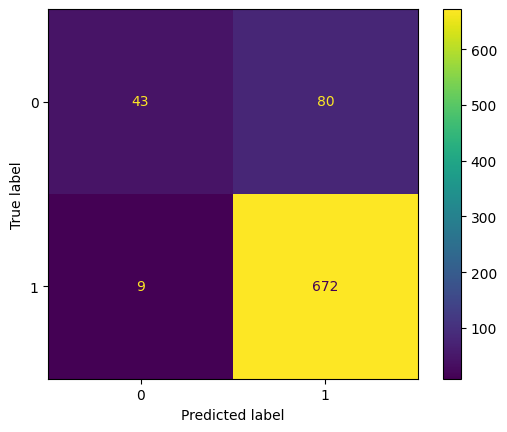

In [ ]:
#I created a confusion matrix diagram to display how well my model predicted the mortality status of all new cancer patients in the unseen data subset

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels = logreg.classes_)

disp = ConfusionMatrixDisplay(cm, display_labels = logreg.classes_)

disp.plot()

Code Leveraged from Code Reuse Session 2,Block 18

In [ ]:
#I examined other foundation-combined performance metrics as my mortality status model's accuracy classification performance on unseen data can be misleading
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.35      0.49       123
           1       0.89      0.99      0.94       681

    accuracy                           0.89       804
   macro avg       0.86      0.67      0.71       804
weighted avg       0.88      0.89      0.87       804



Code Leveraged from Code Reuse Session 2,Block 19

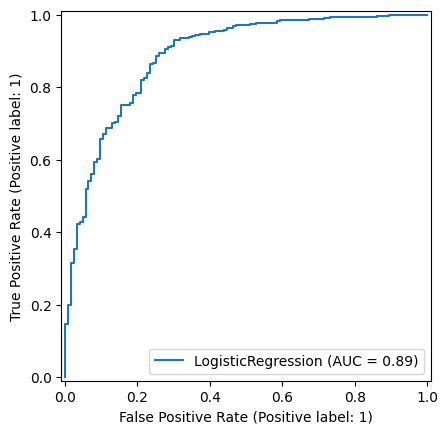

In [ ]:
#The Area Under the Operator Characteristic Curve (AUC-ROC) can give a good indication of the model's discriminative ability between "Dead" and "Alive" mortality classes hence i created a function to display this
from sklearn.metrics import RocCurveDisplay

logreg = RocCurveDisplay.from_estimator(logreg, X1_test, y_test)

Code Leveraged from Code Reuse Session 2,Block 25

In [ ]:
#This code block tunes my model's hyperparameters and displays the best combination of hyperparameters using my desired data subset
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
param_grid = {'C': np.logspace(-4, 4, 20), 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
logreg = LogisticRegression()
logreg1_gscv = GridSearchCV(logreg, param_grid, cv=5, scoring='roc_auc')
logreg1_gscv.fit(X1, y)

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                         'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
             scoring='roc_auc')

Code Leveraged from seminar week 4, block 28

In [ ]:
#This code shows the best K value with the lowest mean error
logreg1_gscv.best_params_

{'C': np.float64(3792.690190732246), 'penalty': 'l2', 'solver': 'liblinear'}

Code Leveraged from Code Reuse Session 2,Block 26

In [ ]:
#I used my built model with optimised hyperparameters to predict mortality status on my test data subset.
y_pred1 = logreg1_gscv.predict(X1_test)

Code Leveraged from seminar week 4, block 41

In [ ]:
#I examined other foundation-combined performance metrics as my mortality status model's accuracy classification performance on unseen data can be misleading
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.80      0.54      0.64       123
           1       0.92      0.98      0.95       681

    accuracy                           0.91       804
   macro avg       0.86      0.76      0.80       804
weighted avg       0.90      0.91      0.90       804



Code Leveraged from Code Reuse Session 2,Block 17

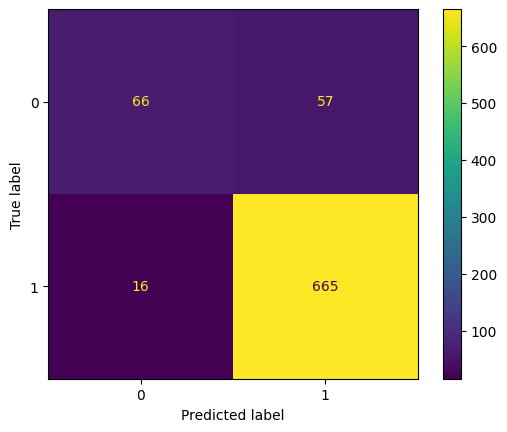

In [ ]:
#I created a confusion matrix diagram to display how well my model predicted the mortality status of all new cancer patients in the unseen data subset
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm2 = confusion_matrix(y_test, y_pred1, labels=logreg1_gscv.best_estimator_.classes_)

disp = ConfusionMatrixDisplay(cm2, display_labels=logreg1_gscv.best_estimator_.classes_)
disp.plot()

Code Leveraged from seminar week 4, block 43

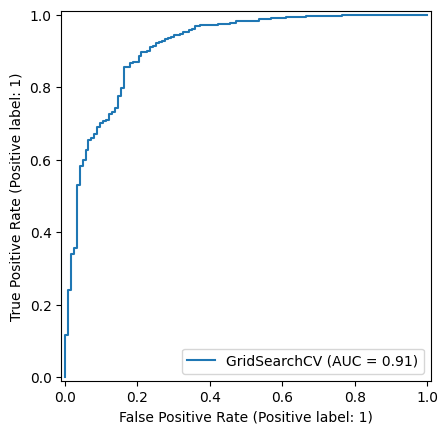

In [ ]:
#The Area Under the Operator Characteristic Curve (AUC-ROC) can give a good indication of the model's discriminative ability between "Dead" and "Alive" mortality classes hence i created a function to display this
knn1_roc = RocCurveDisplay.from_estimator(logreg1_gscv, X1_test, y_test)

Code Leveraged from Code Reuse Session 2,Block 20

In [ ]:
#to build my machine learning models to predict a patient's mortality status, my first need to initiate a machine learning library and function to use the KNN modelling algorithm
from sklearn.neighbors import KNeighborsClassifier

Code Leveraged from Code Reuse Session 2,Block 21

In [ ]:
#This it declares my K-Nearest Neighbour modelling algorithm in the Python environment
knn = KNeighborsClassifier(n_neighbors = 4)

Code Leveraged from Code Reuse Session 2,Block 22

In [ ]:
#To build my K-Nearest Neighbour for mortality status prediction, my algorithm must use a subset of the original dataset to predict the mortality status classification of each new patient's data point
knn.fit(X1_train,y_train)

KNeighborsClassifier(n_neighbors=4)

Code Leveraged from Code Reuse Session 2,Block 23

In [ ]:
#now that I have already built my K-Nearest Neighbour model for mortality status prediction. It is time to make predictions on my isolated unseen data subset
y_pred_knn1 = knn.predict(X1_test)

Code Leveraged from Code Reuse Session 2,Block 19

In [ ]:
#I examined other foundation-combined performance metrics as my mortality status model's accuracy classification performance on unseen data can be misleading
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn1))

              precision    recall  f1-score   support

           0       0.58      0.54      0.56       123
           1       0.92      0.93      0.92       681

    accuracy                           0.87       804
   macro avg       0.75      0.73      0.74       804
weighted avg       0.87      0.87      0.87       804



Code Leveraged from Code Reuse Session 2,Block 17

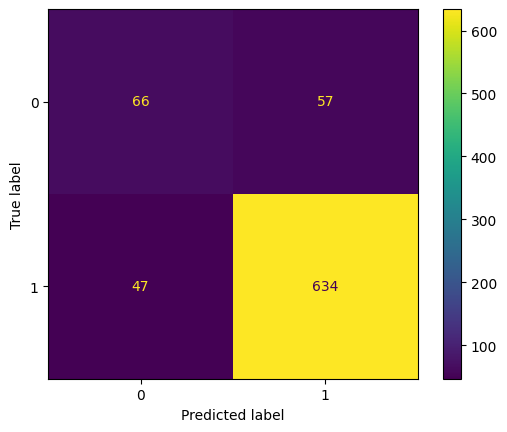

In [ ]:
#I created a confusion matrix diagram to display how well my model predicted the mortality status of all new cancer patients in the unseen data subset
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm1 = confusion_matrix(y_test, y_pred_knn1, labels = knn.classes_)

disp = ConfusionMatrixDisplay(cm1, display_labels = knn.classes_)

disp.plot()

Code Leveraged from seminar week 4,Block 20

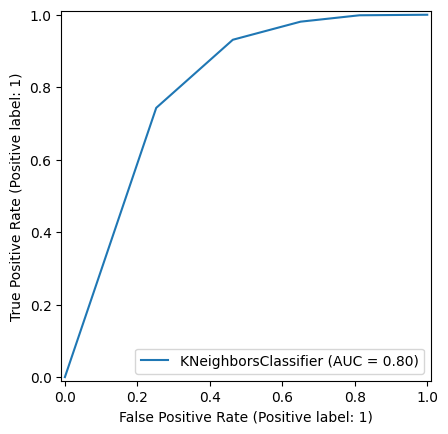

In [ ]:
#The Area Under the Operator Characteristic Curve (AUC-ROC) can give a good indication of the model's discriminative ability between "Dead" and "Alive" mortality classes hence i created a function to display this
knn1_roc = RocCurveDisplay.from_estimator(knn, X1_test, y_test)

Code Leveraged from seminar week 4, block 21

Text(0, 0.5, 'Mean Error')

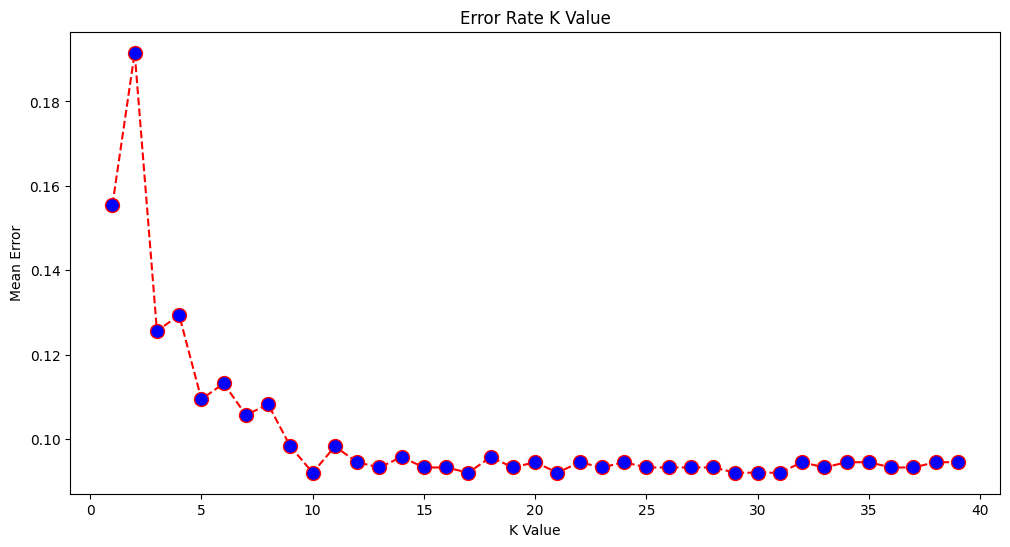

In [ ]:
#This code allows me to view a graph the mean error for the first 40 k values so i can see which K value has the lowest mean error
error = []
import numpy as np
import matplotlib.pyplot as plt
for i in range(1, 40):
    knn1 = KNeighborsClassifier(n_neighbors=i)
    knn1.fit(X1_train, y_train)
    pred_i = knn1.predict(X1_test)
    error.append(np.mean(pred_i != y_test))
plt.figure(figsize=(12, 6))
plt.plot(range(1, 40), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

Code Leveraged from Code Reuse Session 2,Block 24

In [ ]:
#To find the best combination of hyperparameters for an algorithm, I used a validation method known as nested cross-validation
from sklearn.model_selection import GridSearchCV

Code Leveraged from Code Reuse Session 2,Block 25

In [ ]:
#This code block tunes my model's hyperparameters and displays the best combination of hyperparameters using my desired data subset

#optimise for rucauccurve
import numpy as np
knn1 = KNeighborsClassifier()
param_grid = {'n_neighbors': np.arange(1, 40), 'metric': ['euclidean', 'manhattan']}
knn1_gscv = GridSearchCV(knn, param_grid, cv=5, scoring = 'roc_auc')
knn1_gscv.fit(X1, y)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=4),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39])},
             scoring='roc_auc')

Code Leveraged from seminar week 4, block 28

In [ ]:
#This code shows the best K value with the lowest mean error
knn1_gscv.best_params_

{'metric': 'manhattan', 'n_neighbors': np.int64(39)}

Code Leveraged from Code Reuse Session 2,Block 26

In [ ]:
#I used my built model with optimised hyperparameters to predict mortality status on my test data subset.
y_pred_knn2 = knn1_gscv.predict(X1_test)

Code Leveraged from Code Reuse Session 2,Block 16

In [ ]:
#I decided to calculate the accuracy score only to assess how well my model predicts the mortality status of new cancer patients
knn1_accuracy = accuracy_score(y_test, y_pred_knn2)

print ("The accuracy is: ", knn1_accuracy)

The accuracy is:  0.9116915422885572


Code Leveraged from seminar week 4, block 41

In [ ]:
#I examined other foundation-combined performance metrics as my mortality status model's accuracy classification performance on unseen data can be misleading
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn2))

              precision    recall  f1-score   support

           0       0.86      0.50      0.64       123
           1       0.92      0.99      0.95       681

    accuracy                           0.91       804
   macro avg       0.89      0.74      0.79       804
weighted avg       0.91      0.91      0.90       804



Code Leveraged from Code Reuse Session 2,Block 17

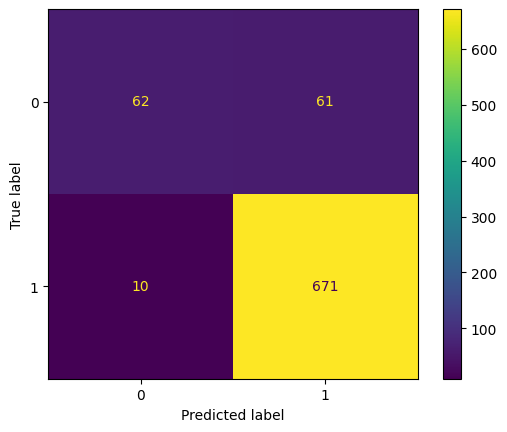

In [ ]:
#I created a confusion matrix diagram to display how well my model predicted the mortality status of all new cancer patients in the unseen data subset
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm2 = confusion_matrix(y_test, y_pred_knn2, labels=knn1_gscv.best_estimator_.classes_)

disp = ConfusionMatrixDisplay(cm2, display_labels=knn1_gscv.best_estimator_.classes_)
disp.plot()

Code Leveraged from seminar week 4, block 43

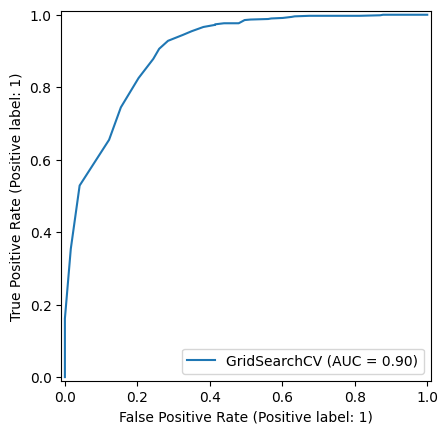

In [ ]:
#The Area Under the Operator Characteristic Curve (AUC-ROC) can give a good indication of the model's discriminative ability between "Dead" and "Alive" mortality classes hence i created a function to display this
knn1_roc = RocCurveDisplay.from_estimator(knn1_gscv, X1_test, y_test)

Code Leveraged from Code Reuse Session 2,Block 27

In [ ]:
#with Naive Bayes, I first need to initiate a machine learning library and the Naive Bayes modelling algorithm. Then, train it with my training data subset
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X1_train, y_train)

GaussianNB()

Code Leveraged from seminar week 4, block 40

In [ ]:
#This code lets me predict the y using the x test
y_pred_nb=nb.predict(X1_test)

Code Leveraged from seminar week 4, block 41

In [ ]:
#I examined other foundation-combined performance metrics as my mortality status model's accuracy classification performance on unseen data can be misleading
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.47      0.57      0.51       123
           1       0.92      0.88      0.90       681

    accuracy                           0.84       804
   macro avg       0.69      0.73      0.71       804
weighted avg       0.85      0.84      0.84       804



Code Leveraged from seminar week 4, block 42

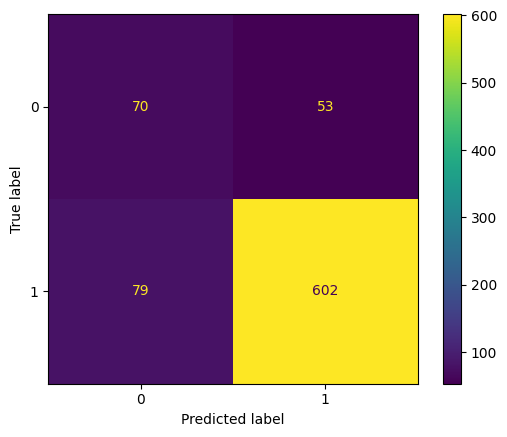

In [ ]:
#I created a confusion matrix diagram to display how well my model predicted the mortality status of all new cancer patients in the unseen data subset
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
nb_cm = confusion_matrix(y_test, y_pred_nb, labels = nb.classes_)
nb_cm = ConfusionMatrixDisplay(nb_cm, display_labels = nb.classes_)
nb_cm.plot()

Code Leveraged from seminar week 4, block 43

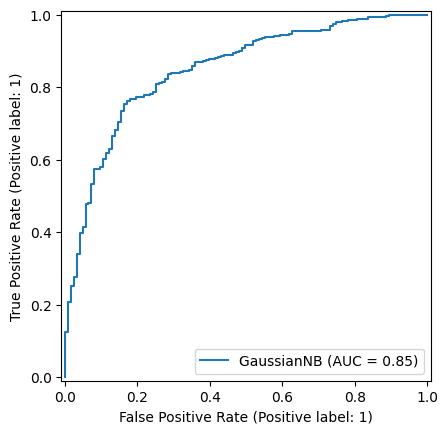

In [ ]:
#The Area Under the Operator Characteristic Curve (AUC-ROC) can give a good indication of the model's discriminative ability between "Dead" and "Alive" mortality classes hence i created a function to display this
from sklearn.metrics import RocCurveDisplay
nb_roc = RocCurveDisplay.from_estimator(nb, X1_test, y_test)